# Assignment 1 — Data

**Lucas Sato Coelho de Oliveira**


| Seção | Conteúdo | Figuras |
|---|---|---|
| Exercício 1 | Nuvens de pontos em 2D, espalhamento e separabilidade | 1, 1b, 2, 3 |
| Exercício 2 | Não-linearidade em 5D, PCA, estrutura radial | 4, 5 |
| Exercício 3 | Pré-processamento do Spaceship Titanic para `tanh` | 6 |
| Results summary | Índice dos valores calculados | — |

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

rng = np.random.default_rng(42)

RESULTS = {}

---
# Exercise 1 — Point Clouds: Geometry and Spread in 2D



## A — Generate the clouds

In [3]:
NAMES = ['Class 0', 'Class 1', 'Class 2', 'Class 3']
MEAN = np.array([[2, 3], [5, 6], [8, 1], [15, 4]])
STD = np.array([[0.8, 2.5], [1.2, 1.9], [0.9, 0.9], [0.5, 2.0]])
N = 100

Z = rng.normal(0, 1, size=(len(MEAN), N, 2))

def generate_clouds(mean, std, z, scale=1.0):
    '''As médias ficam fixas; todo desvio é multiplicado por `scale`.'''

    X = mean[:, None, :] + (std * scale)[:, None, :] * z
    return X.reshape(-1, 2), np.repeat(np.arange(len(mean)), z.shape[1])

X1, y1 = generate_clouds(MEAN, STD, Z, scale=1.0)
print('X:', X1.shape, '| y:', y1.shape, '| pontos por classe:', np.bincount(y1))

X: (400, 2) | y: (400,) | pontos por classe: [100 100 100 100]


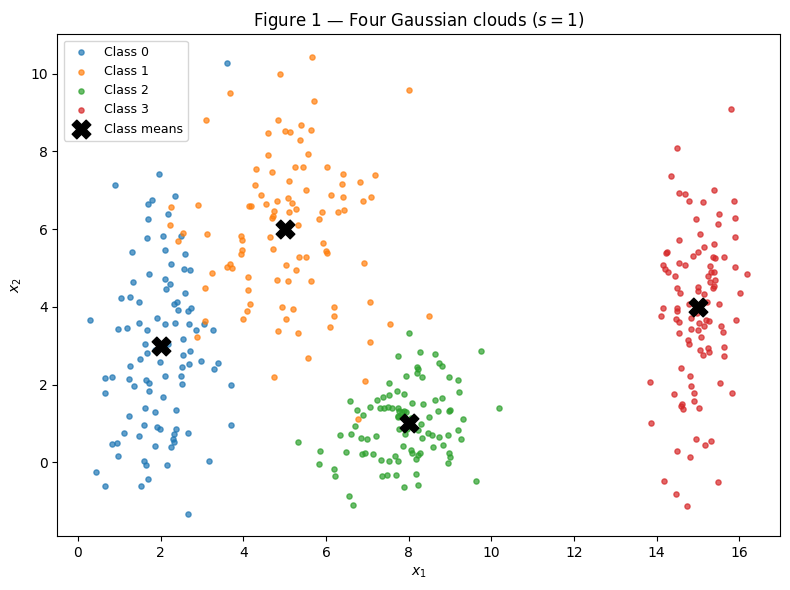

In [4]:
plt.figure(figsize=(8, 6))

for c in range(len(NAMES)):
    m = y1 == c
    plt.scatter(X1[m, 0], X1[m, 1], s=14, alpha=0.7, label=NAMES[c])

plt.scatter(MEAN[:, 0], MEAN[:, 1], marker='X', s=180, c='black',
            zorder=5, label='Class means')

plt.title('Figure 1 — Four Gaussian clouds ($s = 1$)')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## B — More or less spread out

### B.1 — Figure 2

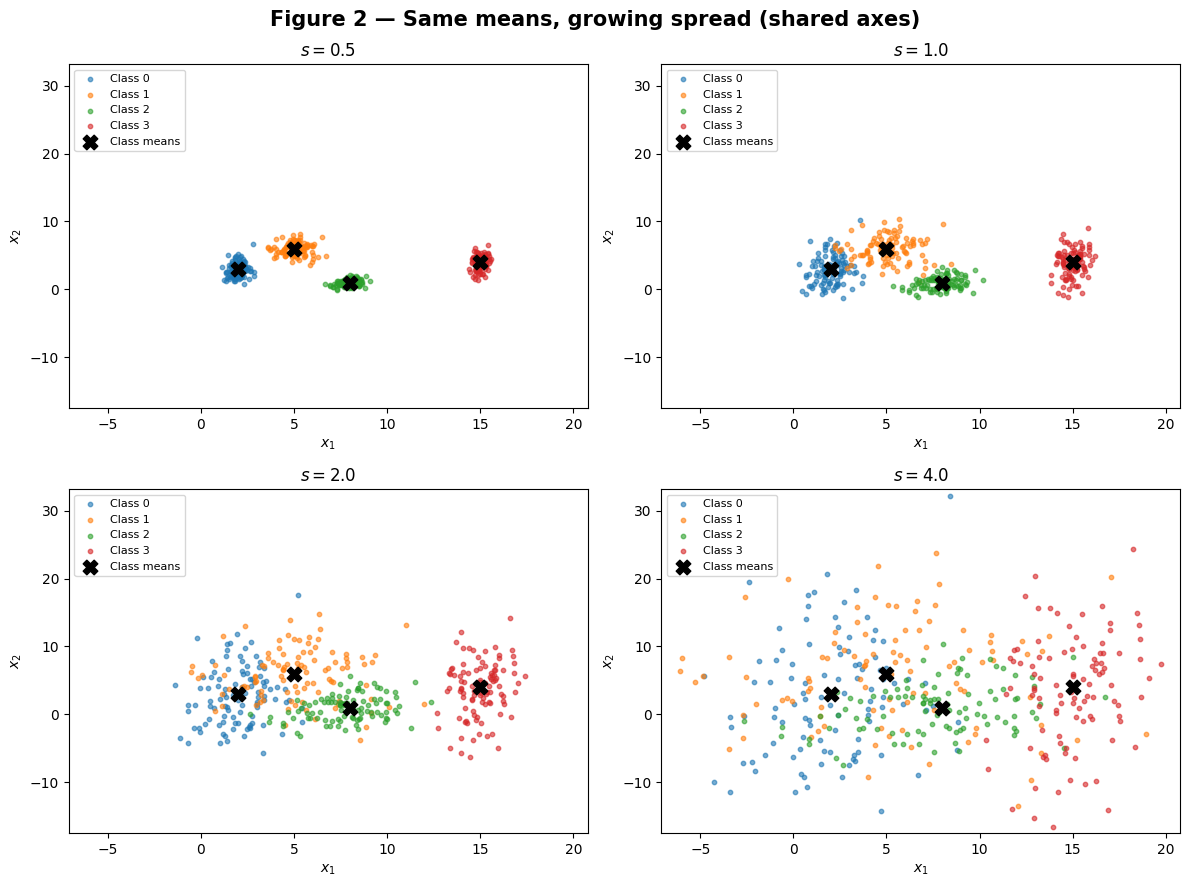

s = 0.5:  X (400, 2)  |  pontos por classe [100 100 100 100]
s = 1.0:  X (400, 2)  |  pontos por classe [100 100 100 100]
s = 2.0:  X (400, 2)  |  pontos por classe [100 100 100 100]
s = 4.0:  X (400, 2)  |  pontos por classe [100 100 100 100]


In [5]:
SCALES = [0.5, 1.0, 2.0, 4.0]

datasets = {sc: generate_clouds(MEAN, STD, Z, scale=sc) for sc in SCALES}

all_pts = np.vstack([X for X, _ in datasets.values()])
xlim = (all_pts[:, 0].min() - 1, all_pts[:, 0].max() + 1)
ylim = (all_pts[:, 1].min() - 1, all_pts[:, 1].max() + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, sc in zip(axes.flat, SCALES):
    X, y = datasets[sc]
    for c in range(len(NAMES)):
        m = y == c
        ax.scatter(X[m, 0], X[m, 1], s=10, alpha=0.6, label=NAMES[c])
    ax.scatter(MEAN[:, 0], MEAN[:, 1], marker='X', s=110,
               c='black', zorder=5, label='Class means')
    ax.set_title(f'$s = {sc}$')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(loc='upper left', fontsize=8)

fig.suptitle('Figure 2 — Same means, growing spread (shared axes)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

for sc in SCALES:
    X, y = datasets[sc]
    print(f's = {sc}:  X {X.shape}  |  pontos por classe {np.bincount(y)}')

### B.2 — Separation ratio at $s = 1$

$$ r_{ij} = \frac{\lVert \mu_i - \mu_j \rVert}{\bar{\sigma}_i + \bar{\sigma}_j},
\qquad \bar{\sigma}_k = \frac{\sigma_{k,x} + \sigma_{k,y}}{2} $$

In [6]:
sigma_bar = STD.mean(axis=1)

linhas = []
for i in range(len(MEAN)):
    for j in range(i + 1, len(MEAN)):
        dist = np.linalg.norm(MEAN[i] - MEAN[j])
        denom = sigma_bar[i] + sigma_bar[j]
        linhas.append({
            'pair': f'({i}, {j})',
            '||mu_i - mu_j||': dist,
            'sigma_bar_i + sigma_bar_j': denom,
            'r_ij (s=1)': dist / denom,
        })

sep_table = pd.DataFrame(linhas).sort_values('r_ij (s=1)').reset_index(drop=True)
display(sep_table.round(4))

par_min = sep_table.iloc[0]['pair']
r_min = float(sep_table.iloc[0]['r_ij (s=1)'])
RESULTS['r_min'] = r_min
RESULTS['par_min'] = par_min

print(f'Menor r_ij em s = 1: par {par_min}, r = {r_min:.4f}')
print(f'Como r_ij escala com 1/s, em s = 2 esse valor vira '
      f'{r_min:.4f} / 2 = {r_min / 2:.4f} (sem gerar nada novo).')

,pair,||mu_i - mu_j||,sigma_bar_i + sigma_bar_j,r_ij (s=1)
0,"(0, 1)",4.2426,3.20,1.3258
1,"(1, 2)",5.8310,2.45,2.3800
2,"(0, 2)",6.3246,2.55,2.4802
3,"(2, 3)",7.6158,2.15,3.5422
4,"(1, 3)",10.1980,2.80,3.6422
5,"(0, 3)",13.0384,2.90,4.4960


Menor r_ij em s = 1: par (0, 1), r = 1.3258
Como r_ij escala com 1/s, em s = 2 esse valor vira 1.3258 / 2 = 0.6629 (sem gerar nada novo).


Os seis pares, ordenados do menor para o maior: **(0, 1) com r = 1.3258**, (1, 2) com
2.3800, (0, 2) com 2.4802, (2, 3) com 3.5422, (1, 3) com 3.6422 e (0, 3) com 4.4960.

O menor é o par **(0, 1)**, com $r_{01} = 1.3258$. Como as médias não mudam e todo
desvio é multiplicado por $s$, vale $r_{ij}(s) = r_{ij}(1) / s$. Em $s = 2$ o menor
$r_{ij}$ passa a ser **0.6629**.

### B.3 — Mixing rate e Figure 3

In [7]:
def mixing_rate(X, y, means):
    '''Fração de pontos cujo centro mais próximo não é o da própria classe.'''

    dists = np.linalg.norm(X[:, None, :] - means[None, :, :], axis=2)
    return float(np.mean(dists.argmin(axis=1) != y))

mixing = {sc: mixing_rate(X, y, MEAN) for sc, (X, y) in datasets.items()}
RESULTS['mixing'] = mixing

mix_table = pd.DataFrame({
    'scale s': list(mixing.keys()),
    'mixing rate': list(mixing.values()),
    'mixing rate (%)': [100 * v for v in mixing.values()],
    'r_min neste s': [r_min / sc for sc in mixing.keys()],
})
display(mix_table.round(4))

,scale s,mixing rate,mixing rate (%),r_min neste s
0,0.5,0.0025,0.25,2.6517
1,1.0,0.0500,5.00,1.3258
2,2.0,0.2025,20.25,0.6629
3,4.0,0.4300,43.00,0.3315


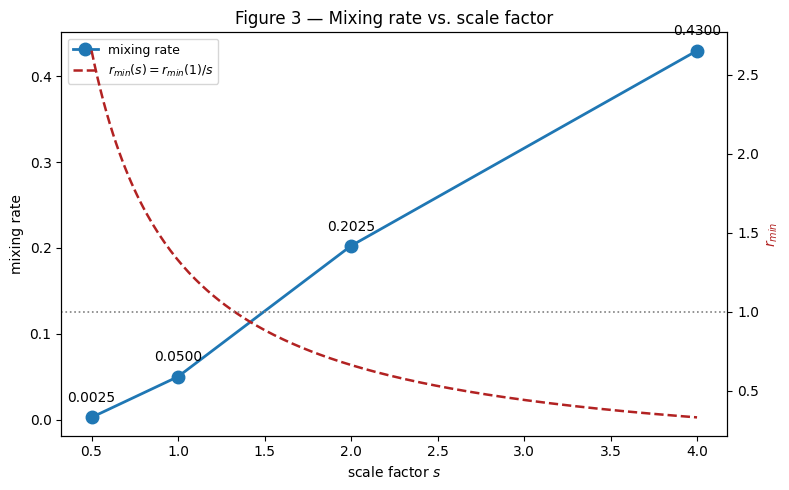

s = 0.5  -> mixing 0.0025 ( 0.25%)   r_min = 2.6517
s = 1.0  -> mixing 0.0500 ( 5.00%)   r_min = 1.3258
s = 2.0  -> mixing 0.2025 (20.25%)   r_min = 0.6629
s = 4.0  -> mixing 0.4300 (43.00%)   r_min = 0.3315


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(list(mixing.keys()), list(mixing.values()), marker='o',
        linewidth=2, markersize=9, label='mixing rate')
for sc, v in mixing.items():
    ax.annotate(f'{v:.4f}', (sc, v), textcoords='offset points',
                xytext=(0, 11), ha='center', fontsize=10)

ax2 = ax.twinx()
s_grid = np.linspace(min(SCALES), max(SCALES), 200)
ax2.plot(s_grid, r_min / s_grid, linestyle='--', color='firebrick',
         linewidth=1.8, label='$r_{min}(s) = r_{min}(1)/s$')
ax2.axhline(1.0, color='grey', linestyle=':', linewidth=1.2)
ax2.set_ylabel('$r_{min}$', color='firebrick')
ax2.grid(False)

ax.set_title('Figure 3 — Mixing rate vs. scale factor')
ax.set_xlabel('scale factor $s$')
ax.set_ylabel('mixing rate')
linhas_leg = ax.get_lines() + ax2.get_lines()[:1]
ax.legend(linhas_leg, [l.get_label() for l in linhas_leg], loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

for sc in SCALES:
    print(f's = {sc:<4} -> mixing {mixing[sc]:.4f} ({mixing[sc]*100:5.2f}%)   '
          f'r_min = {r_min / sc:.4f}')

### B.4 — A partir de qual escala as nuvens deixam de ser separáveis por retas?

As taxas de mistura são **0.0025** em $s = 0.5$, **0.0500** em $s = 1.0$, **0.2025**
em $s = 2.0$ e **0.4300** em $s = 4.0$.

A separabilidade por retas se perde **a partir de $s = 2$**. Até $s = 1$ a mistura
fica em 5%, concentrada numa única fronteira; em $s = 2$ ela salta para 20%, ou seja,
um em cada cinco pontos já está mais perto de um centro que não é o da sua classe.
Esses pontos não podem ser recuperados por fronteira nenhuma, reta ou curva.

O que acontece com o menor $r_{ij}$ nesse ponto é a explicação do fenômeno: ele cai de
1.3258 em $s = 1$ para **0.6629** em $s = 2$, cruzando o valor 1. Enquanto $r_{ij} > 1$
os centros estão mais afastados do que a soma dos espalhamentos e existe um corredor
vazio entre as nuvens; abaixo de 1 esse corredor desaparece e as caudas gaussianas
passam a ocupar o mesmo espaço. Em $s = 4$ o menor $r_{ij}$ já é 0.3315 e a mistura
chega a 43%.

## C — Analysis

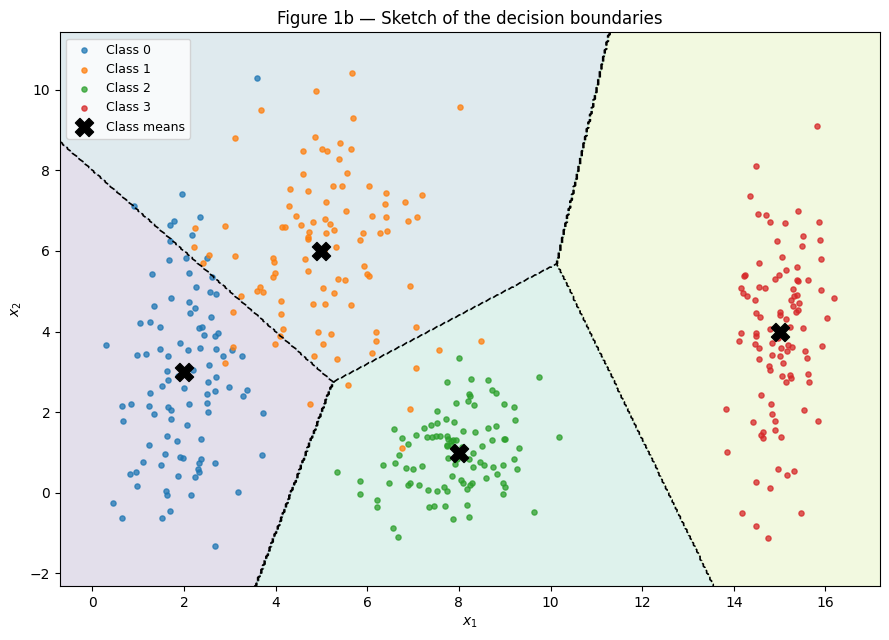

In [9]:
xx, yy = np.meshgrid(np.linspace(X1[:, 0].min() - 1, X1[:, 0].max() + 1, 500),
                     np.linspace(X1[:, 1].min() - 1, X1[:, 1].max() + 1, 500))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = np.linalg.norm(grid[:, None, :] - MEAN[None, :, :], axis=2).argmin(axis=1)
zz = zz.reshape(xx.shape)

plt.figure(figsize=(9, 6.5))
plt.contourf(xx, yy, zz, levels=np.arange(-0.5, len(MEAN)), alpha=0.15)
plt.contour(xx, yy, zz, levels=np.arange(-0.5, len(MEAN)),
            colors='black', linewidths=1.2, linestyles='--')

for c in range(len(NAMES)):
    m = y1 == c
    plt.scatter(X1[m, 0], X1[m, 1], s=14, alpha=0.75, label=NAMES[c])
plt.scatter(MEAN[:, 0], MEAN[:, 1], marker='X', s=170,
            c='black', zorder=5, label='Class means')

plt.title('Figure 1b — Sketch of the decision boundaries')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### C.1 — Sobreposição e separabilidade linear

Em $s = 1$ as classes se misturam num lugar específico, não em geral. Cinco dos seis
pares têm $r_{ij}$ acima de 2.3, ou seja, ficam bem afastados. O único par
problemático é **Classe 0 e Classe 1**, com $r_{01} = 1.3258$ — ainda acima de 1, mas
o mais apertado da tabela. A Classe 3 é a mais isolada, em torno de $x_1 = 15$.

Uma fronteira linear sozinha **não** separa as quatro classes. Uma reta divide o plano
em dois pedaços e são necessárias quatro regiões, então o problema é de contagem, não
de encontrar a reta certa.

Um **conjunto** de fronteiras lineares resolve bem. A taxa de mistura em $s = 1$ é
**0.0500**, e esse é aproximadamente o erro que uma separação por retas cometeria. As
regiões da Figura 1b são delimitadas por segmentos retos, e uma rede com uma camada
escondida e poucos neurônios reproduz esse formato. Os 5% restantes estão quase todos
na fronteira entre a Classe 0 e a Classe 1.

### C.2 — Esboço das fronteiras

O desenho está na Figura 1b. As fronteiras ficam no meio do caminho entre cada par de
centros vizinhos, perpendiculares à reta que os liga. Essa é a posição que deixa a
maior folga possível para os dois lados quando as nuvens têm espalhamento parecido.

Dois pontos que uma rede real reproduz:

- Existem pontos onde três fronteiras se encontram e as três classes ficam
  equidistantes. São os lugares de menor confiança do modelo, com probabilidades de
  saída próximas entre si.
- Onde os desvios são anisotrópicos a fronteira não fica exatamente no meio. A Classe
  0 tem desvio $[0.8,\ 2.5]$, muito mais espalhada na vertical, o que empurra a
  fronteira com a Classe 1 lateralmente. Uma rede também arredondaria os cantos, já
  que ativações suaves não produzem quinas.

### C.3 — Relação com o item B

O que muda entre as escalas é o tamanho da região de erro, não a posição das
fronteiras. Como as médias são fixas, a partição da Figura 1b vale para todas as
escalas — as retas ótimas não dependem de $s$. Muda apenas quantos pontos caem do lado
errado delas.

A imagem útil é uma faixa de ambiguidade colada em cada fronteira: a largura dela
cresce com o desvio, ou seja com $s$, enquanto a distância entre os centros continua
igual. É exatamente isso que $r_{ij}(s) = r_{ij}(1)/s$ mede. O menor $r_{ij}$ cai de
2.6517 em $s = 0.5$ para 0.3315 em $s = 4$, e a taxa de mistura sobe de 0.0025 para
0.4300 no mesmo intervalo.

A consequência prática é que, passado certo espalhamento, aumentar a capacidade da
rede não ajuda. Um modelo mais profundo consegue entortar a fronteira para acertar
pontos específicos do treino, mas esses pontos vêm de distribuições que realmente se
sobrepõem — a contorção está ajustando ruído. O erro de treino cai e o de teste não,
que é overfitting. Vale registrar ainda que a fronteira ótima entre duas gaussianas
com covariâncias parecidas já é uma reta: no regime de alta sobreposição não é a
linearidade que limita o desempenho, é a sobreposição em si.

---
# Exercise 2 — Non-Linearity in Higher Dimensions


## A — Dataset I: shifted Gaussians

In [10]:
DIM = 5
N_5D = 500

MEAN_A = np.array([0.0, 0.0, 0.0, 0.0, 0.0])
MEAN_B = np.array([1.5, 1.5, 1.5, 1.5, 1.5])

COV_A = np.array([
    [1.0, 0.8, 0.1, 0.0, 0.0],
    [0.8, 1.0, 0.3, 0.0, 0.0],
    [0.1, 0.3, 1.0, 0.5, 0.0],
    [0.0, 0.0, 0.5, 1.0, 0.2],
    [0.0, 0.0, 0.0, 0.2, 1.0],
])

COV_B = np.array([
    [ 1.5, -0.7, 0.2, 0.0, 0.0],
    [-0.7,  1.5, 0.4, 0.0, 0.0],
    [ 0.2,  0.4, 1.5, 0.6, 0.0],
    [ 0.0,  0.0, 0.6, 1.5, 0.3],
    [ 0.0,  0.0, 0.0, 0.3, 1.5],
])

XA = rng.multivariate_normal(MEAN_A, COV_A, N_5D)
XB = rng.multivariate_normal(MEAN_B, COV_B, N_5D)

X_ds1 = np.vstack([XA, XB])
y_ds1 = np.concatenate([np.zeros(N_5D, dtype=int),
                        np.ones(N_5D, dtype=int)])

print('Dataset I:', X_ds1.shape)
print('\nMédias empíricas:')
print('  A:', XA.mean(axis=0).round(3))
print('  B:', XB.mean(axis=0).round(3))
print('\nCorrelação empírica entre as features 0 e 1:')
print(f'  A: {np.corrcoef(XA[:, 0], XA[:, 1])[0, 1]:+.3f}  (esperado positivo)')
print(f'  B: {np.corrcoef(XB[:, 0], XB[:, 1])[0, 1]:+.3f}  (esperado negativo)')

Dataset I: (1000, 5)

Médias empíricas:
  A: [0.054 0.078 0.001 0.006 0.006]
  B: [1.541 1.49  1.534 1.555 1.525]

Correlação empírica entre as features 0 e 1:
  A: +0.801  (esperado positivo)
  B: -0.530  (esperado negativo)


As correlações empíricas saem +0.801 para a classe A e −0.530 para a classe B, com os
sinais esperados. O valor da classe B não bate com o −0.7 da matriz porque covariância
e correlação são grandezas diferentes: $-0.7 / \sqrt{1.5 \times 1.5} = -0.467$. Só
coincidem quando a variância é 1, que é o caso da classe A.

## B — Dataset II: concentric shells

In [11]:
RADIUS_C = {'mu': 2.0, 'sigma': 0.4}
RADIUS_D = {'mu': 5.0, 'sigma': 0.4}

def sample_shell(n, dim, mu_r, sigma_r):
    '''Direção uniforme na esfera unitária, raio ~ Normal(mu_r, sigma_r).'''

    directions = rng.normal(0, 1, size=(n, dim))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)

    radii = np.clip(rng.normal(mu_r, sigma_r, n), 0, None)
    return directions * radii[:, None]

XC = sample_shell(N_5D, DIM, RADIUS_C['mu'], RADIUS_C['sigma'])
XD = sample_shell(N_5D, DIM, RADIUS_D['mu'], RADIUS_D['sigma'])

X_ds2 = np.vstack([XC, XD])
y_ds2 = np.concatenate([np.zeros(N_5D, dtype=int),
                        np.ones(N_5D, dtype=int)])

print('Dataset II:', X_ds2.shape)
print(f'raio médio C: {np.linalg.norm(XC, axis=1).mean():.3f}  (alvo {RADIUS_C["mu"]})')
print(f'raio médio D: {np.linalg.norm(XD, axis=1).mean():.3f}  (alvo {RADIUS_D["mu"]})')
print('\nCentros (praticamente coincidentes):')
print('  C:', XC.mean(axis=0).round(3))
print('  D:', XD.mean(axis=0).round(3))

Dataset II: (1000, 5)
raio médio C: 2.010  (alvo 2.0)
raio médio D: 4.979  (alvo 5.0)

Centros (praticamente coincidentes):
  C: [-0.024  0.041 -0.066 -0.026  0.074]
  D: [-0.091 -0.177 -0.185  0.015  0.094]


## C — Visualize and compare

### C.1 — Figure 4

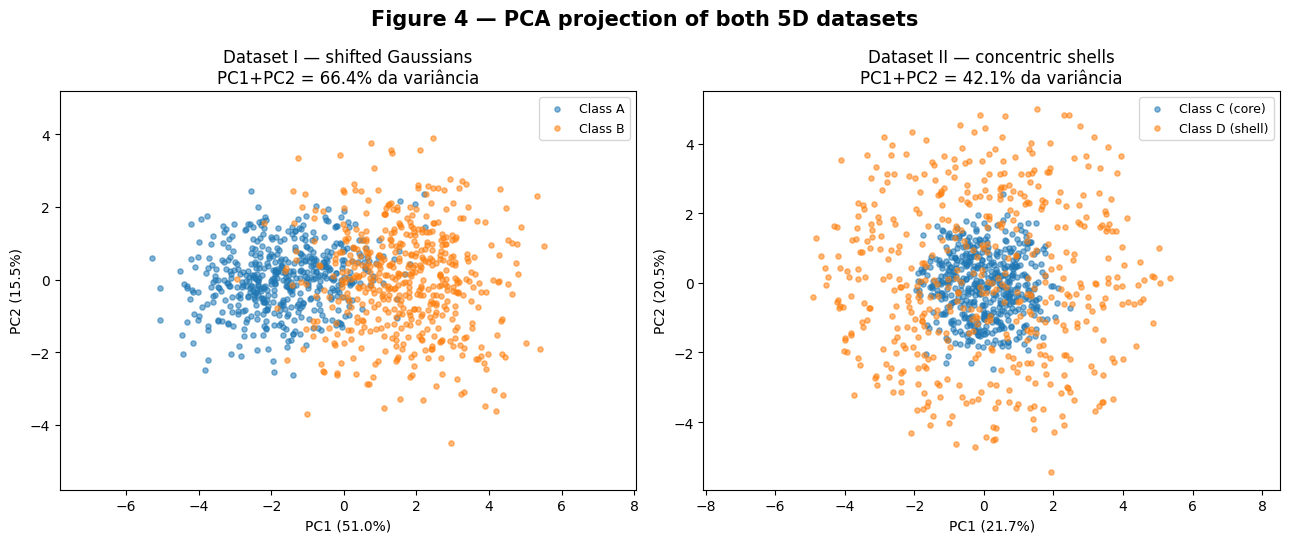

Dataset I  — PC1 0.5096 | PC2 0.1547 | soma 0.6644
Dataset II — PC1 0.2166 | PC2 0.2049 | soma 0.4215


In [12]:
pca1, pca2 = PCA(n_components=2), PCA(n_components=2)
P1 = pca1.fit_transform(X_ds1)
P2 = pca2.fit_transform(X_ds2)

RESULTS['evr1'] = pca1.explained_variance_ratio_
RESULTS['evr2'] = pca2.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

painels = [
    (axes[0], P1, y_ds1, ('Class A', 'Class B'),
     'Dataset I — shifted Gaussians', pca1.explained_variance_ratio_),
    (axes[1], P2, y_ds2, ('Class C (core)', 'Class D (shell)'),
     'Dataset II — concentric shells', pca2.explained_variance_ratio_),
]

for ax, P, y, nomes, titulo, evr in painels:
    for k, nome in enumerate(nomes):
        m = y == k
        ax.scatter(P[m, 0], P[m, 1], s=14, alpha=0.55, label=nome)
    ax.set_title(f'{titulo}\nPC1+PC2 = {evr.sum():.1%} da variância')
    ax.set_xlabel(f'PC1 ({evr[0]:.1%})')
    ax.set_ylabel(f'PC2 ({evr[1]:.1%})')
    ax.legend(fontsize=9)
    ax.set_aspect('equal', adjustable='datalim')

fig.suptitle('Figure 4 — PCA projection of both 5D datasets',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Dataset I  — PC1 {pca1.explained_variance_ratio_[0]:.4f} | '
      f'PC2 {pca1.explained_variance_ratio_[1]:.4f} | '
      f'soma {pca1.explained_variance_ratio_.sum():.4f}')
print(f'Dataset II — PC1 {pca2.explained_variance_ratio_[0]:.4f} | '
      f'PC2 {pca2.explained_variance_ratio_[1]:.4f} | '
      f'soma {pca2.explained_variance_ratio_.sum():.4f}')

### C.2 — Em qual dataset a projeção 2D preserva melhor a informação?

No **Dataset I**, com folga. A variância explicada por PC1 + PC2 é **0.6644** (PC1
0.5096 + PC2 0.1547) contra **0.4215** no Dataset II (PC1 0.2166 + PC2 0.2049).

No Dataset I as duas classes têm centros diferentes, então existe uma direção no
espaço apontando de uma nuvem para a outra. Essa direção concentra bastante variância
justamente porque as classes estão em pontas opostas dela, e como a PCA procura a
direção de maior variância, acaba encontrando exatamente essa. Por isso o painel
esquerdo da Figura 4 mostra dois grupos visíveis.

No Dataset II não existe direção que funcione. As duas cascas dividem o mesmo centro,
então qualquer plano de projeção mostra a bola de dentro sobreposta ao anel de fora —
a sombra de uma casca oca é um disco cheio, não um anel.

O ponto decisivo é que o Dataset II tem variância explicada **menor** e mesmo assim é
o dataset perfeitamente separável, como o item D mostra. Variância explicada e
separabilidade são objetivos diferentes, e esses dois datasets são o contraexemplo que
prova que podem divergir.

### C.3 — Distância entre centros e Figure 5

In [13]:
def centre_distance(X, y):
    '''Distância euclidiana entre os dois centroides, no espaço 5D original.'''
    return float(np.linalg.norm(X[y == 0].mean(axis=0) - X[y == 1].mean(axis=0)))

dist_ds1 = centre_distance(X_ds1, y_ds1)
dist_ds2 = centre_distance(X_ds2, y_ds2)
RESULTS['dist1'] = dist_ds1
RESULTS['dist2'] = dist_ds2

print(f'||mu_A - mu_B||  (Dataset I)  = {dist_ds1:.4f}')
print(f'||mu_C - mu_D||  (Dataset II) = {dist_ds2:.4f}')
print(f'\nReferência teórica do Dataset I: {np.linalg.norm(MEAN_B - MEAN_A):.4f}')

||mu_A - mu_B||  (Dataset I)  = 3.3559
||mu_C - mu_D||  (Dataset II) = 0.2614

Referência teórica do Dataset I: 3.3541


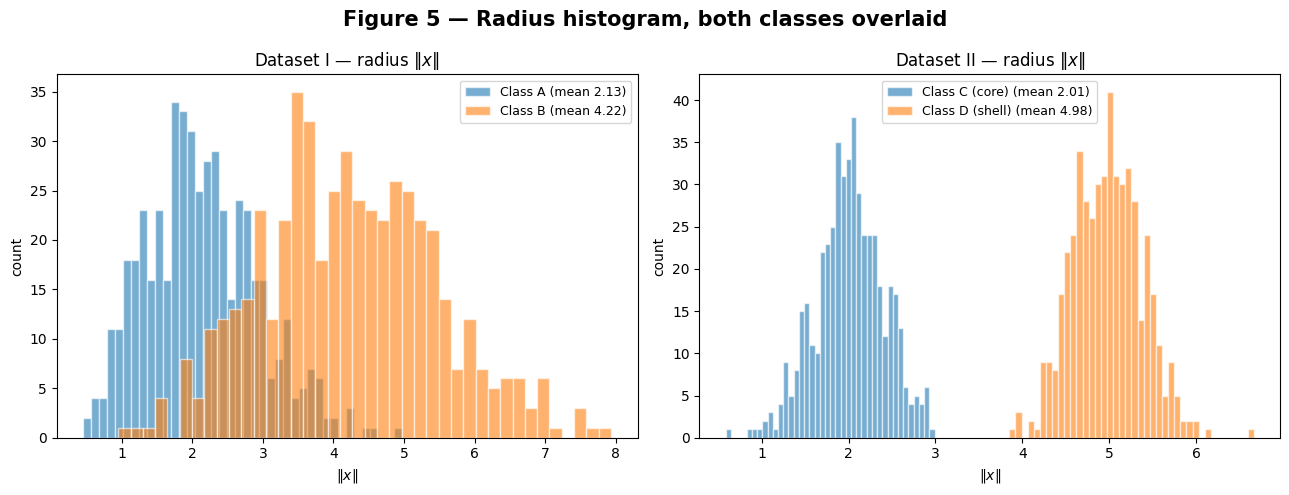

In [14]:
r_ds1 = {'Class A': np.linalg.norm(XA, axis=1),
         'Class B': np.linalg.norm(XB, axis=1)}
r_ds2 = {'Class C (core)': np.linalg.norm(XC, axis=1),
         'Class D (shell)': np.linalg.norm(XD, axis=1)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, radii, titulo in [(axes[0], r_ds1, 'Dataset I'),
                          (axes[1], r_ds2, 'Dataset II')]:
    for nome, r in radii.items():
        ax.hist(r, bins=40, alpha=0.6, edgecolor='white',
                label=f'{nome} (mean {r.mean():.2f})')
    ax.set_title(f'{titulo} — radius $\\|x\\|$')
    ax.set_xlabel('$\\|x\\|$')
    ax.set_ylabel('count')
    ax.legend(fontsize=9)

fig.suptitle('Figure 5 — Radius histogram, both classes overlaid',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

A distância entre os centros é **3.3559** no Dataset I e **0.2614** no Dataset II. O
valor do Dataset I é próximo da referência teórica $\lVert \mu_B - \mu_A \rVert =
3.3541$; o do Dataset II é ruído amostral em torno de zero, como esperado de duas
distribuições que compartilham o centro.

Os histogramas de raio invertem o quadro. No Dataset II as médias são **2.01** e
**4.98**, com desvio 0.4 cada — mais de sete desvios de separação, sem sobreposição
alguma. No Dataset I os raios médios são 2.13 e 4.22, mas as distribuições são largas
e se sobrepõem bastante, porque ali o raio não é a variável informativa.

## D — Analysis

In [15]:
def separate_dataset_ii(X, tau):
    '''Retorna 1 (casca) se soma dos quadrados > tau^2, senão 0 (núcleo).'''
    return (np.sum(X ** 2, axis=1) > tau ** 2).astype(int)

tau = (RADIUS_C['mu'] + RADIUS_D['mu']) / 2
pred = separate_dataset_ii(X_ds2, tau)
RESULTS['sep_acc'] = float(np.mean(pred == y_ds2))

print(f'g(x) = sum(x_i^2) - tau^2,  tau = {tau:.1f}')
print(f'Fração de pontos do lado correto: {RESULTS["sep_acc"]:.4f}')
print(f'Distância entre os centros no Dataset II: {dist_ds2:.4f}')

g(x) = sum(x_i^2) - tau^2,  tau = 3.5
Fração de pontos do lado correto: 1.0000
Distância entre os centros no Dataset II: 0.2614


### D.1

A distância entre os centros do Dataset II é **0.2614**, praticamente zero, enquanto
os histogramas de raio da Figura 5 estão bem separados (médias 2.01 e 4.98). A
combinação mostra que as classes são separáveis, mas não por um hiperplano.

O motivo é que um classificador linear só enxerga a projeção dos pontos sobre uma
direção. Como as duas cascas são simétricas em torno do mesmo centro, qualquer direção
escolhida projeta as duas classes uma sobre a outra, sempre centradas em zero.
Qualquer reta acerta em torno de metade dos pontos.

O raio, por outro lado, separa perfeitamente: as duas distribuições estão a mais de
sete desvios uma da outra e não se tocam. A informação está inteira nos dados, apenas
não numa forma que um modelo linear consiga usar.

### D.2

Mais dados não resolvem porque o problema não é falta de amostra, e sim o tipo de
fronteira que o modelo consegue desenhar.

Uma fronteira linear em 5 dimensões divide o espaço em dois pedaços, e cada pedaço se
estende infinitamente em alguma direção. A região correta aqui é uma casca esférica,
que não tem esse formato. Qualquer fronteira linear erra, e erra igual com mil ou com
um milhão de pontos.

De forma concreta: uma fronteira que englobe toda a classe C, que está perto da
origem, também engloba todos os pontos da classe D que estão do mesmo lado — e D está
espalhada em todas as direções. Não existe onde colocar a reta.

O que resolve é transformar as features. Trocando os cinco valores de $x$ por
$\lVert x \rVert$, o problema vira unidimensional e um limiar resolve. É isso que as
camadas escondidas de uma rede fazem: constroem features novas antes da parte linear.

### D.3

Não prova, e o Dataset II é o próprio contraexemplo.

A PCA é linear — só rotaciona e descarta direções. Quando o gráfico dela mostra as
classes misturadas, a única conclusão possível é que nenhuma projeção linear em 2D
separa. Nada é dito sobre funções não lineares.

A evidência está nos resultados acima: o painel direito da Figura 4 mostra as classes
C e D embaralhadas, e ainda assim um corte único em $\lVert x \rVert$ acerta
**1.0000** dos pontos. Mesmos dados, mesma dimensão, uma imagem que parece impossível
e um separador trivial.

Reforça o argumento o fato de o Dataset II ter variância explicada menor (0.4215
contra 0.6644 do Dataset I) e mesmo assim ser o dataset separável. Variância explicada
alta não significa projeção boa para classificar.

A assimetria vale ser registrada: um gráfico de PCA com classes bem separadas é
evidência **positiva forte**, porque exibe um separador linear concreto. Um gráfico
com classes misturadas é evidência **negativa fraca**, porque descarta apenas a
separabilidade linear naquela projeção.

**Função que separa o Dataset II:**

$$ g(x) = \sum_{i=1}^{5} x_i^2 - \tau^2 $$

Classifica como casca D quando $g(x) > 0$ e como núcleo C quando $g(x) \le 0$. Com
$\tau = 3.5$, o meio do caminho entre os raios 2.0 e 5.0 do enunciado, o resultado é
**1.0000** dos pontos do lado correto. O valor de $\tau$ vem dos parâmetros e não de
um ajuste aos dados.

A soma dos quadrados foi usada em vez da raiz porque a raiz é monótona e não altera a
ordenação, e porque é a forma sugerida pelo enunciado. Note que $g$ é **quadrática**
nos inputs — exatamente o tipo de função que um modelo linear não expressa.

---
# Exercise 3 — Preparing Real-World Data for a Neural Network



## A — Get to know the data

In [18]:
CSV_PATH = 'database/train.csv'
df = pd.read_csv(CSV_PATH)

SPEND_COLS = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
NUM_COLS = ['Age'] + SPEND_COLS
CAT_COLS = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
DROP_COLS = ['PassengerId', 'Name', 'Cabin']
TARGET = 'Transported'

print(f'{df.shape[0]} linhas x {df.shape[1]} colunas')
display(df.head())

8693 linhas x 14 colunas


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [19]:
balance = df[TARGET].value_counts(normalize=True).sort_index()
RESULTS['share_positive'] = float(df[TARGET].mean())

for k, v in balance.items():
    print(f'  {str(k):<6} {v:.4f}  ({int(v * len(df))} passageiros)')

  False  0.4964  (4315 passageiros)
  True   0.5036  (4378 passageiros)


In [20]:
inventario = pd.DataFrame({
    'coluna': df.columns,
    'dtype': [str(t) for t in df.dtypes],
    'n_unicos': [df[c].nunique() for c in df.columns],
    'tipo': [
        'alvo' if c == TARGET else
        'numérica' if c in NUM_COLS else
        'categórica' if c in CAT_COLS else
        'descartada'
        for c in df.columns
    ],
})
display(inventario)

print(f'Numéricas   ({len(NUM_COLS)}): {NUM_COLS}')
print(f'Categóricas ({len(CAT_COLS)}): {CAT_COLS}')
print(f'Descartadas ({len(DROP_COLS)}): {DROP_COLS}')

,coluna,dtype,n_unicos,tipo
0,PassengerId,object,8693,descartada
1,HomePlanet,object,3,categórica
2,CryoSleep,object,2,categórica
3,Cabin,object,6560,descartada
4,Destination,object,3,categórica
5,Age,float64,80,numérica
6,VIP,object,2,categórica
7,RoomService,float64,1273,numérica
8,FoodCourt,float64,1507,numérica
9,ShoppingMall,float64,1115,numérica


Numéricas   (6): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Categóricas (4): ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
Descartadas (3): ['PassengerId', 'Name', 'Cabin']


In [21]:
missing = pd.DataFrame({
    'faltantes': df.isna().sum(),
    'pct': (100 * df.isna().mean()).round(2),
}).sort_values('faltantes', ascending=False)
display(missing)

print(f'Linhas com pelo menos um NaN: {df.isna().any(axis=1).sum()} '
      f'({100 * df.isna().any(axis=1).mean():.1f}%)')

,faltantes,pct
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
Spa,183,2.11
FoodCourt,183,2.11
Destination,182,2.09


Linhas com pelo menos um NaN: 2087 (24.0%)


In [22]:
spend_stats = df[SPEND_COLS].agg(['mean', 'median', 'max', 'std']).T
spend_stats['pct_zero'] = [100 * (df[c] == 0).mean() for c in SPEND_COLS]
display(spend_stats.round(2))

,mean,median,max,std,pct_zero
RoomService,224.69,0.0,14327.0,666.72,64.16
FoodCourt,458.08,0.0,29813.0,1611.49,62.76
ShoppingMall,173.73,0.0,23492.0,604.70,64.27
Spa,311.14,0.0,22408.0,1136.71,61.24
VRDeck,304.85,0.0,24133.0,1145.72,63.21


### A — Leitura dos resultados

**Objetivo do dataset.** A coluna `Transported` indica se o passageiro foi
transportado para uma dimensão alternativa após a colisão da nave com a anomalia
espaço-temporal. É booleana e é o alvo da classificação. O balanço entre as duas
classes fica praticamente em 50/50, então acurácia é métrica justa e não há
necessidade de reponderação ou reamostragem.

**Tipos de feature.** Seis numéricas (`Age` e as cinco colunas de gasto), quatro
categóricas (`HomePlanet`, `CryoSleep`, `Destination`, `VIP`) e três descartadas
(`PassengerId`, `Name`, `Cabin`) por serem identificadores ou texto livre. `CryoSleep`
e `VIP` são booleanas, mas como têm valores faltantes o pandas as guarda como
`object`; ficam tratadas como categóricas.

**Faltantes.** Nenhuma coluna está gravemente danificada — todas ficam em torno de 2%
—, mas os buracos estão espalhados por linhas diferentes, de modo que descartar linhas
incompletas eliminaria uma fatia grande do dataset. Imputar é a escolha melhor.

**Média × mediana dos gastos.** A mediana das cinco colunas é **0** enquanto as médias
ficam na casa das centenas e os máximos chegam à casa dos milhares. Três leituras
decorrem disso. Primeiro, a maioria dos passageiros não gastou nada, o que a coluna
`pct_zero` confirma — em boa parte são os passageiros em criosono, que não têm como
consumir. Segundo, as distribuições são fortemente assimétricas à direita: média muito
acima da mediana é a assinatura clássica, e o desvio padrão fica inflado junto.
Terceiro, valores crus nessa escala são incompatíveis com `tanh` — uma entrada na casa
dos milhares satura a unidade instantaneamente, com derivada zero, e o neurônio morre
antes do primeiro passo de gradiente. É isso que motiva o $\log(1+x)$ do item C.

## B — Split before you transform

In [23]:
X_raw = df.drop(columns=DROP_COLS + [TARGET])
y_raw = df[TARGET].astype(int)

X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_raw, y_raw,
    test_size=0.20,
    stratify=y_raw,
    random_state=42,
)

RESULTS['fc_mean'] = float(X_tr_raw['FoodCourt'].mean())
RESULTS['fc_median'] = float(X_tr_raw['FoodCourt'].median())

print(f'Treino: {X_tr_raw.shape}   taxa positiva {y_tr.mean():.4f}')
print(f'Teste:  {X_te_raw.shape}   taxa positiva {y_te.mean():.4f}')
print(f'\nFoodCourt no TREINO, antes de qualquer transformação:')
print(f'  média   = {RESULTS["fc_mean"]:.4f}')
print(f'  mediana = {RESULTS["fc_median"]:.4f}')

Treino: (6954, 10)   taxa positiva 0.5036
Teste:  (1739, 10)   taxa positiva 0.5037

FoodCourt no TREINO, antes de qualquer transformação:
  média   = 452.6112
  mediana = 0.0000


### B.2 — Por que o split vem antes

Toda estatística usada nas transformações é informação extraída dos dados: a mediana
que preenche uma idade faltante, o mínimo e o máximo que reescalam uma coluna, a lista
de categorias conhecida pelo encoder. Calculá-las no dataset inteiro e separar depois
faz com que as linhas de teste influenciem como as de treino são transformadas, e o
teste deixa de ser um conjunto não visto.

O efeito não é apenas conceitual: a nota de teste fica otimista e para de indicar como
o modelo se comportaria com passageiros novos. Como estimar isso é o motivo de existir
um conjunto de teste, vazar informação para dentro dele anula o propósito da
separação.

A regra seguida daqui em diante é `fit` no treino e `transform` nos dois conjuntos.

## C — Preprocess

### C.1 — Missing data

In [24]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

num_imputer.fit(X_tr_raw[NUM_COLS])
cat_imputer.fit(X_tr_raw[CAT_COLS].astype(object))

def impute(X):
    out = X.copy()
    out[NUM_COLS] = num_imputer.transform(X[NUM_COLS])
    out[CAT_COLS] = cat_imputer.transform(X[CAT_COLS].astype(object))
    return out

X_tr = impute(X_tr_raw)
X_te = impute(X_te_raw)

print('Valores aprendidos no TREINO:')
for c, v in zip(NUM_COLS, num_imputer.statistics_):
    print(f'  {c:<14} mediana -> {v}')
for c, v in zip(CAT_COLS, cat_imputer.statistics_):
    print(f'  {c:<14} moda    -> {v}')

print(f'\nNaN restantes — treino: {X_tr.isna().sum().sum()}, '
      f'teste: {X_te.isna().sum().sum()}')

Valores aprendidos no TREINO:
  Age            mediana -> 27.0
  RoomService    mediana -> 0.0
  FoodCourt      mediana -> 0.0
  ShoppingMall   mediana -> 0.0
  Spa            mediana -> 0.0
  VRDeck         mediana -> 0.0
  HomePlanet     moda    -> Earth
  CryoSleep      moda    -> False
  Destination    moda    -> TRAPPIST-1e
  VIP            moda    -> False

NaN restantes — treino: 0, teste: 0


### C.2 — Categorical features

In [25]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_tr[CAT_COLS].astype(str))

ohe_names = list(ohe.get_feature_names_out(CAT_COLS))
tr_cat = pd.DataFrame(ohe.transform(X_tr[CAT_COLS].astype(str)),
                      columns=ohe_names, index=X_tr.index)
te_cat = pd.DataFrame(ohe.transform(X_te[CAT_COLS].astype(str)),
                      columns=ohe_names, index=X_te.index)

print(f'{len(CAT_COLS)} colunas categóricas -> {len(ohe_names)} colunas indicadoras:')
for n in ohe_names:
    print('   ', n)

demo = X_te[CAT_COLS].astype(str).head(1).copy()
demo.iloc[0, 0] = 'Pluto'
n_hp = sum(n.startswith('HomePlanet') for n in ohe_names)
print(f"\nCategoria inédita 'Pluto' em HomePlanet -> soma do bloco = "
      f"{ohe.transform(demo)[0][:n_hp].sum():.0f}")

4 colunas categóricas -> 10 colunas indicadoras:
    HomePlanet_Earth
    HomePlanet_Europa
    HomePlanet_Mars
    CryoSleep_False
    CryoSleep_True
    Destination_55 Cancri e
    Destination_PSO J318.5-22
    Destination_TRAPPIST-1e
    VIP_False
    VIP_True

Categoria inédita 'Pluto' em HomePlanet -> soma do bloco = 0


### C.3 — Feature engineering

In [26]:
for X in (X_tr, X_te):
    X['TotalSpend'] = X[SPEND_COLS].sum(axis=1)

ENGINEERED = SPEND_COLS + ['TotalSpend']
display(X_tr['TotalSpend'].describe().to_frame().T.round(2))

,count,mean,std,min,25%,50%,75%,max
TotalSpend,6954.0,1426.55,2755.56,0.0,0.0,715.0,1442.0,35987.0


### C.4 — Heavy tails

In [27]:
for X in (X_tr, X_te):
    for c in ENGINEERED:
        X[c] = np.log1p(X[c])

comparacao = pd.DataFrame({
    'antes (cru)': np.expm1(X_tr['FoodCourt']).describe(),
    'depois log1p': X_tr['FoodCourt'].describe(),
})
display(comparacao.round(3))

print(f"assimetria antes:  {pd.Series(np.expm1(X_tr['FoodCourt'])).skew():.3f}")
print(f"assimetria depois: {X_tr['FoodCourt'].skew():.3f}")

,antes (cru),depois log1p
count,6954.000,6954.000
mean,442.588,1.883
std,1586.019,2.921
min,0.000,0.000
25%,0.000,0.000
50%,0.000,0.000
75%,54.750,4.021
max,29813.000,10.303


assimetria antes:  7.376
assimetria depois: 1.163


**Por que o log ajuda uma rede com `tanh`.** A `tanh` é praticamente linear perto de
zero e plana fora de aproximadamente $[-2, 2]$, com derivada $1 - \tanh^2(z)$ que
tende a zero conforme $|z|$ cresce. Um valor de gasto na casa dos milhares satura a
unidade: a saída trava em $\pm 1$, o gradiente é numericamente nulo e a
retropropagação não passa sinal. O neurônio fica morto durante todo o treino.

Só reescalar não resolve. Padronizando uma coluna em que 90% da massa está no zero e
alguns pontos estão em dezenas de milhares, os valores padronizados ficam próximos de
$-0.1$ para quase todo mundo e muito acima disso para os outliers. Quase todos os
dados caem numa fatia estreita onde a função não discrimina, e os outliers continuam
saturando. O problema é a **forma** da distribuição, e só uma transformação não linear
muda forma.

O $\log(1+x)$ comprime a cauda de modo multiplicativo — a diferença entre 100 e 1.000
créditos passa a valer o mesmo que entre 1.000 e 10.000, o que é indiscutivelmente a
leitura mais razoável de gasto. Depois dele, reescalar de fato espalha os dados pela
região útil da curva.

### C.5 — Scaling

In [28]:
NUMERIC_FINAL = ['Age'] + ENGINEERED

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(X_tr[NUMERIC_FINAL])

tr_num = pd.DataFrame(scaler.transform(X_tr[NUMERIC_FINAL]),
                      columns=NUMERIC_FINAL, index=X_tr.index)
te_num = pd.DataFrame(scaler.transform(X_te[NUMERIC_FINAL]),
                      columns=NUMERIC_FINAL, index=X_te.index)

X_train_final = pd.concat([tr_num, tr_cat], axis=1)
X_test_final = pd.concat([te_num, te_cat], axis=1)

RESULTS['train_min'] = float(X_train_final.values.min())
RESULTS['train_max'] = float(X_train_final.values.max())
RESULTS['test_min'] = float(X_test_final.values.min())
RESULTS['test_max'] = float(X_test_final.values.max())
RESULTS['train_shape'] = X_train_final.shape

print(f'TREINO: [{RESULTS["train_min"]:.4f}, {RESULTS["train_max"]:.4f}]')
print(f'TESTE:  [{RESULTS["test_min"]:.4f}, {RESULTS["test_max"]:.4f}]')
print(f'\nShape treino: {X_train_final.shape}')
print(f'Shape teste:  {X_test_final.shape}')

TREINO: [-1.0000, 1.0000]
TESTE:  [-1.0000, 1.1383]

Shape treino: (6954, 17)
Shape teste:  (1739, 17)


### C — Justificativa das escolhas

**Imputação.** Numéricas com mediana, porque as colunas de gasto têm cauda longa e a
média seria puxada pelos poucos valores altíssimos, preenchendo os faltantes com um
número que não representa quase ninguém. Categóricas com a moda, já que com cerca de
2% de faltantes por coluna a categoria mais frequente adiciona pouco ruído. Uma
alternativa seria criar uma categoria explícita "Missing".

**Categoria inédita no teste.** `handle_unknown='ignore'` faz o encoder colocar zero
em todas as colunas do grupo quando a categoria não foi vista no treino, em vez de
levantar erro. A linha mantém o mesmo número de colunas. O teste com `"Pluto"` em
`HomePlanet` confirma: a soma do bloco daquela linha fica em 0.

**Scaling.** A escolha foi Normalization para $[-1, 1]$. Como a `tanh` devolve valores
nesse intervalo, manter a entrada na mesma faixa evita que qualquer valor sature a
primeira camada logo no início. A Standardization deixaria o intervalo aberto e um
valor extremo ainda poderia virar um z-score alto o bastante para saturar. A
desvantagem do MinMax é a sensibilidade ao mínimo e máximo do treino, contornada
aplicando-o depois do $\log(1+x)$, com a cauda já comprimida.

## D — Verify and visualize

### D.1 — Figure 6

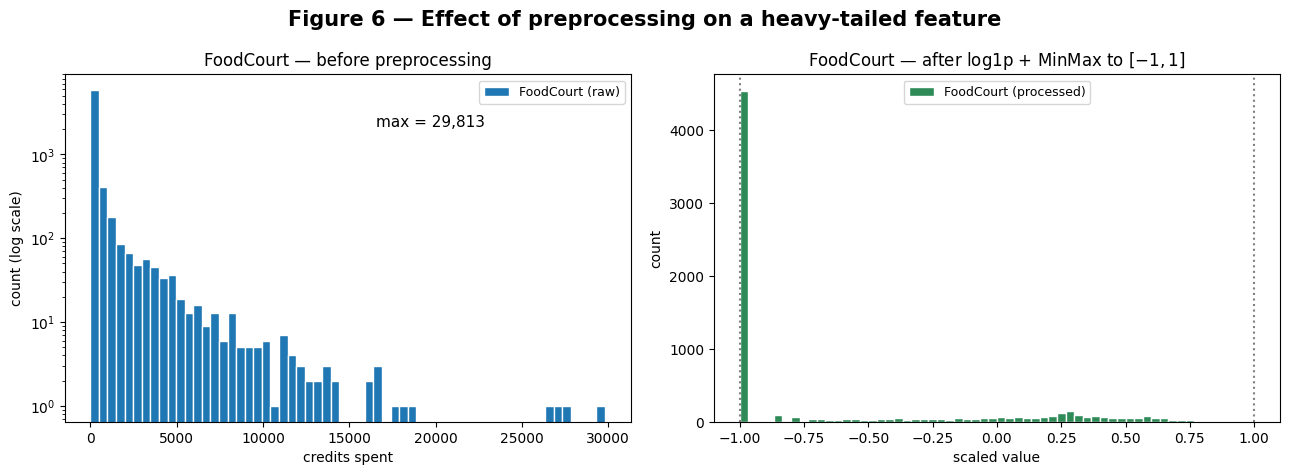

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

raw_fc = X_tr_raw['FoodCourt'].fillna(X_tr_raw['FoodCourt'].median())
axes[0].hist(raw_fc, bins=60, edgecolor='white', label='FoodCourt (raw)')
axes[0].set_title('FoodCourt — before preprocessing')
axes[0].set_xlabel('credits spent')
axes[0].set_ylabel('count (log scale)')
axes[0].set_yscale('log')
axes[0].legend(fontsize=9)
axes[0].annotate(f'max = {raw_fc.max():,.0f}', xy=(0.55, 0.85),
                 xycoords='axes fraction', fontsize=11)

axes[1].hist(X_train_final['FoodCourt'], bins=60, edgecolor='white',
             color='seagreen', label='FoodCourt (processed)')
axes[1].set_title('FoodCourt — after log1p + MinMax to $[-1, 1]$')
axes[1].set_xlabel('scaled value')
axes[1].set_ylabel('count')
axes[1].axvline(-1, color='grey', linestyle=':')
axes[1].axvline(1, color='grey', linestyle=':')
axes[1].legend(fontsize=9)

fig.suptitle('Figure 6 — Effect of preprocessing on a heavy-tailed feature',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### D.2 — Final checks

In [30]:
checks = {
    'Sem NaN no treino': int(X_train_final.isna().sum().sum()) == 0,
    'Sem NaN no teste': int(X_test_final.isna().sum().sum()) == 0,
    'Treino e teste com as mesmas colunas':
        list(X_train_final.columns) == list(X_test_final.columns),
    'Todos os valores finitos':
        bool(np.isfinite(X_train_final.values).all() and
             np.isfinite(X_test_final.values).all()),
    'Treino dentro de [-1, 1]':
        RESULTS['train_min'] >= -1.0001 and RESULTS['train_max'] <= 1.0001,
    'Teste compatível com tanh (|v| < 2)':
        max(abs(RESULTS['test_min']), abs(RESULTS['test_max'])) < 2.0,
}

for nome, ok in checks.items():
    print(f"  [{'OK' if ok else 'FALHOU'}] {nome}")

print(f'\nShape final do treino: {X_train_final.shape}')
print(f'Shape final do teste:  {X_test_final.shape}')
print(f'Intervalo treino: [{RESULTS["train_min"]:.4f}, {RESULTS["train_max"]:.4f}]')
print(f'Intervalo teste:  [{RESULTS["test_min"]:.4f}, {RESULTS["test_max"]:.4f}]')
print(f'\nColunas ({X_train_final.shape[1]}): {list(X_train_final.columns)}')
display(X_train_final.head().round(3))

  [OK] Sem NaN no treino
  [OK] Sem NaN no teste
  [OK] Treino e teste com as mesmas colunas
  [OK] Todos os valores finitos
  [OK] Treino dentro de [-1, 1]
  [OK] Teste compatível com tanh (|v| < 2)

Shape final do treino: (6954, 17)
Shape final do teste:  (1739, 17)
Intervalo treino: [-1.0000, 1.0000]
Intervalo teste:  [-1.0000, 1.1383]

Colunas (17): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'CryoSleep_False', 'CryoSleep_True', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'VIP_False', 'VIP_True']


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpend,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_False,CryoSleep_True,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_False,VIP_True
3600,-1.000,-1.0,-1.0,-1.000,-1.000,-1.000,-1.000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1262,-0.570,-1.0,-1.0,-1.000,-1.000,-1.000,-1.000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
8612,-0.114,-1.0,-1.0,-1.000,-1.000,-1.000,-1.000,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
5075,-0.342,-1.0,-1.0,-1.000,-1.000,-1.000,-1.000,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4758,-0.671,-1.0,-1.0,-0.127,-0.862,0.723,0.632,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


### D — Análise

**Figura 6.** O eixo y do painel esquerdo está em escala logarítmica; sem isso a barra
dos zeros domina o gráfico e o resto da distribuição desaparece. Antes, os valores vão
de 0 ao máximo impresso na figura, com quase toda a massa empilhada no zero. Depois do
$\log(1+x)$ e do MinMax, a coluna fica entre $-1$ e $1$, com o pico em $-1$
correspondendo aos passageiros que não gastaram nada e o restante distribuído ao longo
do intervalo.

**Checagens.** Todas passaram: nenhum NaN nos dois conjuntos, colunas idênticas entre
treino e teste, valores finitos, treino dentro de $[-1, 1]$ e teste dentro de faixa
compatível com `tanh`. O treino atinge exatamente $-1$ e $1$ porque é assim que o
MinMax funciona. O teste pode ultrapassar ligeiramente quando algum valor lá é maior
que o máximo visto no treino — comportamento esperado e correto, já que cortar o teste
para caber no intervalo seria vazamento.

**Qual decisão mais afetaria o treino.** O $\log(1+x)$ nas colunas de gasto. As demais
escolhas são refinamentos; essa é a que decide se a rede treina ou não. Essas cinco
colunas são as mais informativas do dataset, porque gasto está fortemente ligado ao
estado de criosono, que por sua vez está ligado ao alvo. São também as de maior faixa
dinâmica. Sem o $\log(1+x)$, qualquer reescala linear preserva a forma da
distribuição: quase todos os passageiros ficam espremidos num intervalo minúsculo onde
a `tanh` não os distingue, e os poucos valores altos ficam saturados com gradiente
zero. As features mais informativas chegariam à rede no formato menos aproveitável.

Em segundo lugar viria a escolha do scaling, por motivo relacionado: ela define se a
primeira camada começa na região responsiva da `tanh` ou já saturada. A imputação é a
menos crítica das três — com cerca de 2% de faltantes, mediana ou média deslocam a
acurácia final numa fração de ponto percentual. Vale uma ressalva contra a própria
escolha feita aqui: imputar `CryoSleep` pela moda descarta um sinal, já que
`CryoSleep` ausente combinado com gasto zero é indício razoável de que o passageiro
estava em criosono. Uma coluna indicadora de "faltante" provavelmente seria uma
pequena melhora.

---
# Results summary

Tabela gerada pela célula abaixo a partir dos valores calculados ao longo do
relatório.

In [32]:
G = RESULTS
mix = G['mixing']

linhas_sumario = [
    (1, 'Mixing rate at s = 0.5', f'{mix[0.5]:.4f}'),
    (2, 'Mixing rate at s = 1.0', f'{mix[1.0]:.4f}'),
    (3, 'Mixing rate at s = 2.0', f'{mix[2.0]:.4f}'),
    (4, 'Mixing rate at s = 4.0', f'{mix[4.0]:.4f}'),
    (5, 'Smallest r_ij at s = 1.0, and which pair',
        f'{G["r_min"]:.4f} — pair {G["par_min"]}'),
    (6, 'Distance between centers — Dataset I', f'{G["dist1"]:.4f}'),
    (7, 'Distance between centers — Dataset II', f'{G["dist2"]:.4f}'),
    (8, 'Explained variance PC1 + PC2 — Dataset I',
        f'{G["evr1"].sum():.4f} (PC1 {G["evr1"][0]:.4f} + PC2 {G["evr1"][1]:.4f})'),
    (9, 'Explained variance PC1 + PC2 — Dataset II',
        f'{G["evr2"].sum():.4f} (PC1 {G["evr2"][0]:.4f} + PC2 {G["evr2"][1]:.4f})'),
    (10, 'Share of the positive class in Transported', f'{G["share_positive"]:.4f}'),
    (11, 'Mean and median of FoodCourt on the training set, before transforming',
        f'mean {G["fc_mean"]:.4f} | median {G["fc_median"]:.4f}'),
    (12, 'Final shape of the training feature matrix', str(G['train_shape'])),
    (13, 'Minimum and maximum of the training and test sets after scaling',
        f'train [{G["train_min"]:.4f}, {G["train_max"]:.4f}] | '
        f'test [{G["test_min"]:.4f}, {G["test_max"]:.4f}]'),
]

sumario = pd.DataFrame(linhas_sumario, columns=['#', 'Item', 'Your value']).set_index('#')
display(sumario)



,Item,Your value
#,,
1,Mixing rate at s = 0.5,0.0025
2,Mixing rate at s = 1.0,0.0500
3,Mixing rate at s = 2.0,0.2025
4,Mixing rate at s = 4.0,0.4300
5,"Smallest r_ij at s = 1.0, and which pair","1.3258 — pair (0, 1)"
6,Distance between centers — Dataset I,3.3559
7,Distance between centers — Dataset II,0.2614
8,Explained variance PC1 + PC2 — Dataset I,0.6644 (PC1 0.5096 + PC2 0.1547)
9,Explained variance PC1 + PC2 — Dataset II,0.4215 (PC1 0.2166 + PC2 0.2049)


---
## Uso de ferramentas de IA

Conforme a política de colaboração da atividade, este relatório foi desenvolvido com
auxílio de assistente de IA (Anthropic Claude) na estruturação do código e na revisão
do texto (principalmente na elaboração de gráficos). Todo o código foi executado e verificado, e cada etapa pode ser explicada
sob solicitação.
